In [1]:
import networkx as nx
import numpy as np
import math
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import random
import shapely
from typing import Dict, List, Optional, Self

In [ ]:

# Plot polygon graph.
world = generate_world(
    {
        "seed": 0,
        "start": (5.0, 5.0),
        "goal": (100.0, 100.0),
        "obstacles": {
            "number_of_squares": 2,
            "length_range": (5.0, 10.0),
            "theta_range": (0.0, 180.0),
            "x_range": (30.0, 70.0),
            "y_range": (30.0, 70.0),
        },
    }
)
polygon_graph = build_polygon_graph(world["obstacles"])
nx.draw(polygon_graph, pos={node[1]["id"]: node[1]["coord"].coords[0] for node in polygon_graph.nodes(data=True)})

In [2]:
def generate_square(len: float) -> shapely.Polygon:
    """Returns a square polygon that its width and length are `len`.

    Args:
        len (float): Length of a square.

    Returns:
        shapely.Polygon: Generated square centered at origin.
    """
    return shapely.Polygon(
        (
            (len / 2, len / 2),
            (len / 2, -len / 2),
            (-len / 2, -len / 2),
            (-len / 2, len / 2),
            (len / 2, len / 2),
        )
    )


def rotate_and_translate(
    g: shapely.geometry, theta: float, x: float, y: float
) -> shapely.geometry:
    """Rotates and translates the given geometry `g`.

    Args:
        g (shapely.geometry): Geometry to be transformed.
        theta (float): Angle (degree) to rotate.
        x (float): Translation along x-axis.
        y (float): Translation along y-axis.

    Returns:
        shapely.geometry: Rotated and translated geometry.
    """
    return shapely.affinity.translate(shapely.affinity.rotate(g, theta), x, y)

def generate_world2(config: Dict) -> Dict[str, shapely.Geometry]:
    """Generates a world depicted by the given `config`.

    Args:
        config (Dict): Configuration of the world.
        e.g.,
        {
            "start"     : (0.0, 0.0),
            "goal"      : (100.0, 100.0),
            "obstacles" : {
                "number_of_squares" : 10,
                "length_range"      : (1.0, 5.0),
                "theta_range"       : (0.0, 360.0),
                "x_range"           : (10.0, 90.0),
                "y_range"           : (10.0, 90.0)
            }
        }

    Returns:
        Dict[str, shapely.Geometry]: Generated world.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
    """
    xs = [30, 60]
    ys = [40, 80]
    squares = [
        rotate_and_translate(
            generate_square(random.uniform(5, 5)),
            random.uniform(0, 0),
            random.uniform(xs[i], xs[i]),
            random.uniform(ys[i], ys[i]),
        )
        for i in range(config["obstacles"]["number_of_squares"])
    ]
    union = shapely.union_all(squares)
    if isinstance(union, shapely.Polygon):
        union = shapely.GeometryCollection((union))
    polygons = []
    for geom in union.geoms:
        polygons.append(shapely.Polygon(geom.exterior.coords))
    return {
        "start": shapely.Point((config["start"])),
        "goal": shapely.Point((config["goal"])),
        "obstacles": shapely.MultiPolygon(polygons),
    }


def draw_world(
    world: Dict[str, shapely.Geometry],
    graph: shapely.MultiLineString = shapely.MultiLineString(()),
):
    """Draws the given world and visibility graph.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
        graph (shapely.MultiLineString): Edges of visibility graph.
    """
    fig, ax = plt.subplots()
    ax.plot(*world["start"].xy, "ro", label="start")
    ax.plot(*world["goal"].xy, "rx", label="goal")
    for obstacle in world["obstacles"].geoms:
        ax.add_patch(
            patches.Polygon(
                obstacle.exterior.coords,
                fc="green",
                lw=1.0,
                color="black",
                ls="--",
                alpha=0.5,
            )
        )
    for edge in graph.geoms:
        ax.plot(*edge.coords.xy, color="blue", lw=1.0)
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

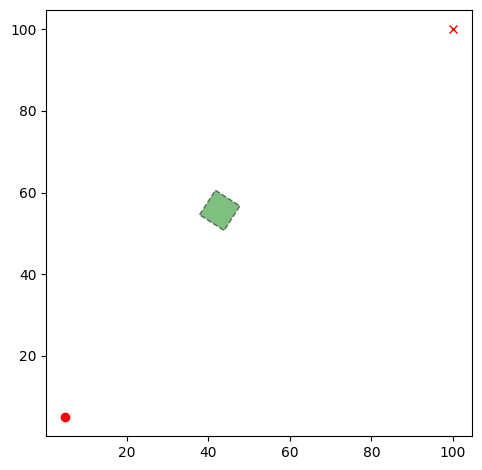

In [3]:
world = generate_world(
    {
        "start": (5.0, 5.0),
        "goal": (100.0, 100.0),
        "obstacles": {
            "number_of_squares": 1,
            "length_range": (5.0, 10.0),
            "theta_range": (0.0, 180.0),
            "x_range": (30.0, 70.0),
            "y_range": (30.0, 70.0),
        },
    }
)
draw_world(world)

In [ ]:
def build_polygon_graph(polygons: shapely.MultiPolygon) -> nx.Graph:
    """Builds a graph of which the vertices are points, and the edges are the sides.

    Args:
        polygons (shapely.MultiPolygon): Obstacles.

    Returns:
        nx.Graph: A graph representing the polygons.
    """
    id = 0
    graph = nx.Graph()
    for polygon in polygons.geoms:
        offset = id
        for i in range(len(polygon.exterior.coords) - 1):
            graph.add_node(id, id=id, coord=shapely.Point(polygon.exterior.coords[i]))
            id += 1
        for i in range(len(polygon.exterior.coords) - 2):
            graph.add_edge(offset + i, offset + i + 1)
        graph.add_edge(offset, offset + len(polygon.exterior.coords) - 2)
    return graph

In [ ]:
def construct_edges(
    p: shapely.Point, polygons: shapely.MultiPolygon
) -> shapely.MultiLineString:
    """Returns visibility graph edges spanning from `p`.

    Args:
        p (shapely.Point): Start or goal points.
        polygons (shapely.MultiPolygon): Obstacles.

    Returns:ß
        shapely.MultiLineString: Edges of the generated visibility graph.
    """
    graph = []
    for polygon in polygons.geoms:
        for q in polygon.exterior.coords[:-1]:
            ls = shapely.LineString((p, q))
            if ls.touches(polygons):
                graph.append(ls)
    return shapely.MultiLineString(graph)

In [ ]:
class Side:
    """A class representing a side of a polygon."""

    def __init__(self, src_id: int, dst_id: int, polygon_graph: nx.Graph):
        """C'tor.

        Args:
            src_id (int): ID of source vertex.
            dst_id (int): ID of destination vertex.
            polygon_graph (nx.Graph): A graph representing polygons.
        """
        if src_id > dst_id:
            self.__init__(dst_id, src_id, polygon_graph)
            return
        self.src_id = src_id
        self.dst_id = dst_id
        self.side = shapely.LineString(
            (polygon_graph.nodes[src_id]["coord"], polygon_graph.nodes[dst_id]["coord"])
        )
        self.left = None
        self.right = None

    def is_equal(self, rhs: Self) -> bool:
        """Returns whether the `rhs` side is equals to self.

        Args:
            rhs (Self): A side.

        Returns:
            bool: True if self and the given side are equal.
        """
        return self.src_id == rhs.src_id and self.dst_id == rhs.dst_id

    def is_less_equal(self, sweep_line: shapely.LineString, rhs: Self) -> bool:
        """Returns whether self <= `rhs` on the given sweep line.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            rhs (Self): A side.

        Returns:
            bool: Whether this <= `rhs` on the given sweep line.
        """
        start = sweep_line.coords[0]

        length_self = None
        for intersect in sweep_line.intersection(self.side, grid_size=1e-2).coords:
            length = np.hypot(intersect[0] - start[0], intersect[1] - start[1])
            length_self = (
                length if length_self is None or length < length_self else length_self
            )

        length_rhs = None
        for intersect in sweep_line.intersection(rhs.side, grid_size=1e-2).coords:
            length = np.hypot(intersect[0] - start[0], intersect[1] - start[1])
            length_rhs = (
                length if length_rhs is None or length < length_rhs else length_rhs
            )

        return length_self <= length_rhs

In [ ]:
class CandidateSides:
    """A class for candidate sides."""

    def __init__(self):
        """C'tor."""
        self.root = None

    def get_min(self) -> Optional[Side]:
        """Gets the minimum side.

        Returns:
            Side: A minimum side.
        """
        return self._get_min(self.root)

    def _get_min(self, root: Optional[Side]) -> Optional[Side]:
        """Gets the minimum side from a tree rooted at `root`.

        Args:
            root (Optional[Side]): A root.

        Returns:
            Optional[Side]: A minimum side.
        """
        if root is None:
            return None
        elif root.left is not None:
            return self._get_min(root.left)
        else:
            return root

    def get_max(self) -> Optional[Side]:
        """Gets the maximum side.

        Returns:
            Side: A maximum side.
        """
        return self._get_max(self.root)

    def _get_max(self, root: Optional[Side]) -> Optional[Side]:
        """Gets the maximum side from a tree rooted at `root`.

        Args:
            root (Optional[Side]): A root.

        Returns:
            Optional[Side]: A maximum side.
        """
        if root is None:
            return None
        elif root.right is not None:
            return self._get_max(root.right)
        else:
            return root

    def insert(self, sweep_line: shapely.LineString, side: Side) -> Side:
        """Inserts a side to the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            side (Side): A side to insert.

        Returns:
            Side: A root of inserted tree.
        """
        self.root = self._insert(sweep_line, self.root, side)
        return self.root

    def _insert(
        self, sweep_line: shapely.LineString, root: Optional[Side], side: Side
    ) -> Side:
        """Inserts a side to the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            root (Optional[Side]): A root.
            side (Side): A side to insert.

        Returns:
            Side: A root of inserted tree.
        """
        if root is None:
            root = side
        elif side.is_less_equal(sweep_line, root):
            root.left = self._insert(sweep_line, root.left, side)
        else:
            root.right = self._insert(sweep_line, root.right, side)
        return root

    def delete(self, sweep_line: shapely.LineString, side: Side) -> Optional[Side]:
        """Deletes a side from the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            side (Side): Side to delete.

        Returns:
            Optional[Side]: A root of deleted tree.
        """
        self.root = self._delete(sweep_line, self.root, side)
        return self.root

    def _delete(
        self, sweep_line: shapely.LineString, root: Optional[Side], side: Side
    ) -> Optional[Side]:
        """Deletes a side from the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            root (Optional[Side]): A root.
            side (Side): Side to delete.

        Returns:
            Optional[Side]: A root of deleted tree.
        """
        if root is None:
            return None
        elif root.is_equal(side):
            if root.left is None:
                return root.right
            elif root.right is None:
                return root.left
            else:
                max_side = self._get_max(root.left)
                root.src_id = max_side.src_id
                root.dst_id = max_side.dst_id
                root.side = max_side.side
                root.left = self._delete(sweep_line, root.left, max_side)
        elif side.is_less_equal(sweep_line, root):
            root.left = self._delete(sweep_line, root.left, side)
        else:
            root.right = self._delete(sweep_line, root.right, side)
        return root

    def traverse(self):
        """Inorder traverse."""
        self._traverse(self.root)
        print("\n")

    def _traverse(self, root: Optional[Side]):
        """Inorder traverse of the tree rooted at `root`,

        Args:
            root (Optional[Side]): A root.
        """
        if root is None:
            return
        self._traverse(root.left)
        print(f"({root.src_id}, {root.dst_id})")
        self._traverse(root.right)

In [ ]:
def get_visible_points(
    p: shapely.Point, polygons: shapely.MultiPolygon, polygon_graph: nx.Graph
) -> shapely.MultiPoint:
    """Returns points that are visible from `p`.

    Args:
        p (shapely.Point): A point.
        polygons (shapely.MultiPolygon): Obstacles.
        polygon_graph (nx.Graph): A polygon graph.

    Returns:
        shapely.MultiPoint: Visible points.
    """

    print(f"p: {p}")

    def make_sweep_line(p: shapely.Point, q: shapely.Point) -> shapely.LineString:
        pnpy = np.array([p.x, p.y])
        qnpy = np.array([q.x, q.y])
        dir = qnpy - pnpy
        norm = np.linalg.norm(dir)
        dir *= 1e2
        dir /= norm
        return shapely.LineString((p, (p.x + dir[0], p.y + dir[1])))

    candidates = CandidateSides()
    sweep_line = make_sweep_line(p, shapely.Point(p.x + 1, p.y))
    for src_id, dst_id in polygon_graph.edges:
        src = polygon_graph.nodes[src_id]["coord"]
        dst = polygon_graph.nodes[dst_id]["coord"]
        ls = shapely.LineString((src, dst))
        if sweep_line.crosses(ls):
            candidates.insert(sweep_line, Side(src_id, dst_id, polygon_graph))

    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta <= 0 else 2 * math.pi - theta
        return theta

    nodes = []
    for n in polygon_graph.nodes:
        if p != polygon_graph.nodes[n]["coord"]:
            nodes.append(polygon_graph.nodes[n])
    nodes.sort(
        key=lambda q: (
            my_atan2(p, q["coord"]),
            math.hypot(q["coord"].x - p.x, q["coord"].y - p.y),
        )
    )

    def is_cw(ls: shapely.LineString, p: shapely.Point):
        v0 = shapely.Point(
            ls.coords[1][0] - ls.coords[0][0], ls.coords[1][1] - ls.coords[0][1]
        )
        v1 = shapely.Point(p.x - ls.coords[0][0], p.y - ls.coords[0][1])
        cross = v0.x * v1.y - v1.x * v0.y
        return cross < 0

    visible_points = []
    for node in nodes:
        min_side = candidates.get_min()
        sweep_line = make_sweep_line(p, node["coord"])
        print(f"\tsweep_line: {sweep_line} ({p} -> {node['coord']})")
        print(f"\tatan {my_atan2(p, node['coord'])}")
        if min_side is None or not min_side.side.intersects(sweep_line):
            visible_points.append(node["coord"])
        for neighbor in polygon_graph.neighbors(node["id"]):
            side = Side(node["id"], polygon_graph.nodes[neighbor]["id"], polygon_graph)
            if is_cw(sweep_line, polygon_graph.nodes[neighbor]["coord"]):
                print(f"\t\tinserted")
                candidates.insert(sweep_line, side)
            else:
                print("\t\tdeleted")
                candidates.delete(sweep_line, side)
    print(f"\t{visible_points}")

    return visible_points


def generate_world2(config: Dict) -> Dict[str, shapely.Geometry]:
    """Generates a world depicted by the given `config`.

    Args:
        config (Dict): Configuration of the world.
        e.g.,
        {
            "start"     : (0.0, 0.0),
            "goal"      : (100.0, 100.0),
            "obstacles" : {
                "number_of_squares" : 10,
                "length_range"      : (1.0, 5.0),
                "theta_range"       : (0.0, 360.0),
                "x_range"           : (10.0, 90.0),
                "y_range"           : (10.0, 90.0)
            }
        }

    Returns:
        Dict[str, shapely.Geometry]: Generated world.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
    """
    xs = [30, 60]
    ys = [40, 80]
    squares = [
        rotate_and_translate(
            generate_square(random.uniform(5, 5)),
            random.uniform(0, 0),
            random.uniform(xs[i], xs[i]),
            random.uniform(ys[i], ys[i]),
        )
        for i in range(config["obstacles"]["number_of_squares"])
    ]
    union = shapely.union_all(squares)
    if isinstance(union, shapely.Polygon):
        union = shapely.GeometryCollection((union))
    polygons = []
    for geom in union.geoms:
        polygons.append(shapely.Polygon(geom.exterior.coords))
    return {
        "start": shapely.Point((config["start"])),
        "goal": shapely.Point((config["goal"])),
        "obstacles": shapely.MultiPolygon(polygons),
    }


world2 = generate_world2( {
        "start": (5.0, 5.0),
        "goal": (100.0, 100.0),
        "obstacles": {
            "number_of_squares": 2,
            "length_range": (5.0, 10.0),
            "theta_range": (0.0, 180.0),
            "x_range": (30.0, 70.0),
            "y_range": (30.0, 70.0),
        },
    })
draw_world(world2)
construct_visibility_graph_efficiently(world2)
#draw_world(world2, construct_visibility_graph_efficiently(world2))

In [ ]:
def construct_visibility_graph_efficiently(
    world: Dict[str, shapely.Geometry]
) -> List[shapely.LineString]:
    """Constructs a visibility graph using an efficient algorithm.
    This is a skeleton of the D.T Lee's algorithm.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }

    Returns:
        List[shapely.LineString]: Edges of the generated visibility graph.
    """
    graph = []
    polygons = world["obstacles"]
    graph.extend(construct_edges(world["start"], polygons).geoms)
    graph.extend(construct_edges(world["goal"], polygons).geoms)

    polygon_graph = build_polygon_graph(world["obstacles"])

    points = []
    for polygon in polygons.geoms:
        points.extend([shapely.Point(point) for point in polygon.exterior.coords[:-1]])

    for point in points:
        for q in get_visible_points(point, polygons, polygon_graph):
            graph.append(shapely.LineString((point, q)))

    return shapely.MultiLineString(graph)